# Exploration Notebook

Interactive EDA and visualisation. Run the main pipeline with:
```bash
uv run python -m src.backtest
```

In [3]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname("__file__"), ".."))

from src.data import load_data
from src.features import engineer_all_features
from src.backtest import walkforward, print_results
from src.analysis import plot_cumulative_pnl, print_backtest_stats, plot_feature_importance
from src.analysis import plot_target_distributions, check_stationarity, plot_missing_values
from src.analysis import plot_feature_target_correlations, plot_rolling_correlations, plot_feature_correlation_matrix
from src.config import TARGETS

df, feature_cols = load_data()
FEATURE_COLS = [c for c in df.columns if c not in ['Dates'] + TARGETS]

Period:       2000-01-03 → 2025-02-06
Observations: 6,549
Features:     60
Missing:      43.0%


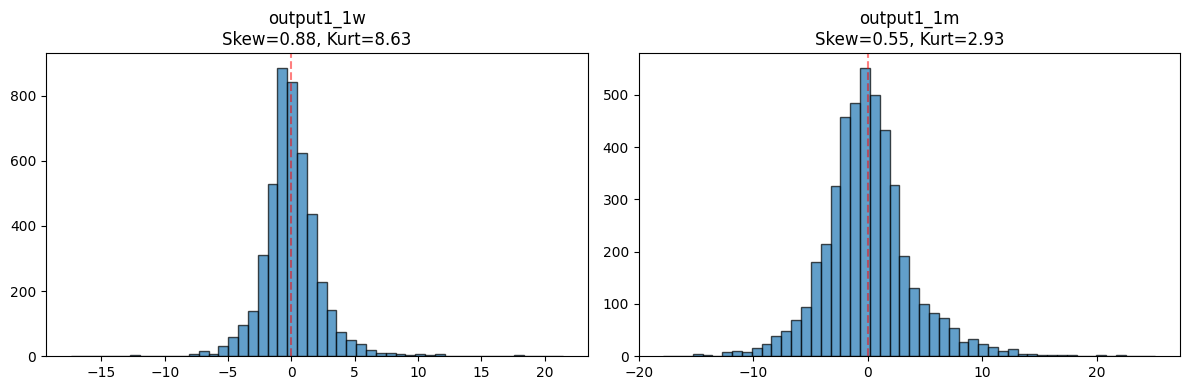

output1_1w: ADF stat=-16.632, p=1.66e-29 → Stationary
output1_1m: ADF stat=-12.016, p=3.10e-22 → Stationary


NameError: name 'FEATURE_COLS' is not defined

<Figure size 1400x400 with 0 Axes>

In [4]:
plot_target_distributions(df, TARGETS)
check_stationarity(df, TARGETS)
plot_missing_values(df)

In [ ]:
plot_feature_target_correlations(df, feature_cols, TARGETS)
plot_rolling_correlations(df, feature_cols, TARGETS)
plot_feature_correlation_matrix(df, feature_cols)

Engineered 254 new features (total: 314)

XGBoost (engineered) — output1_1w (horizon=5d)
 fold     ic  hit_rate  sharpe   max_dd
    1 0.5322    0.6209  2.3923 -15.7865
    2 0.3457    0.6340  2.1810 -20.9473
    3 0.6240    0.7124  3.4633 -24.3876
    4 0.5660    0.6601  3.3230 -14.0918
    5 0.5160    0.7190  3.5842  -6.5504

Mean: IC=0.517, Hit=66.9%, Sharpe=2.99, MaxDD=-16.3527


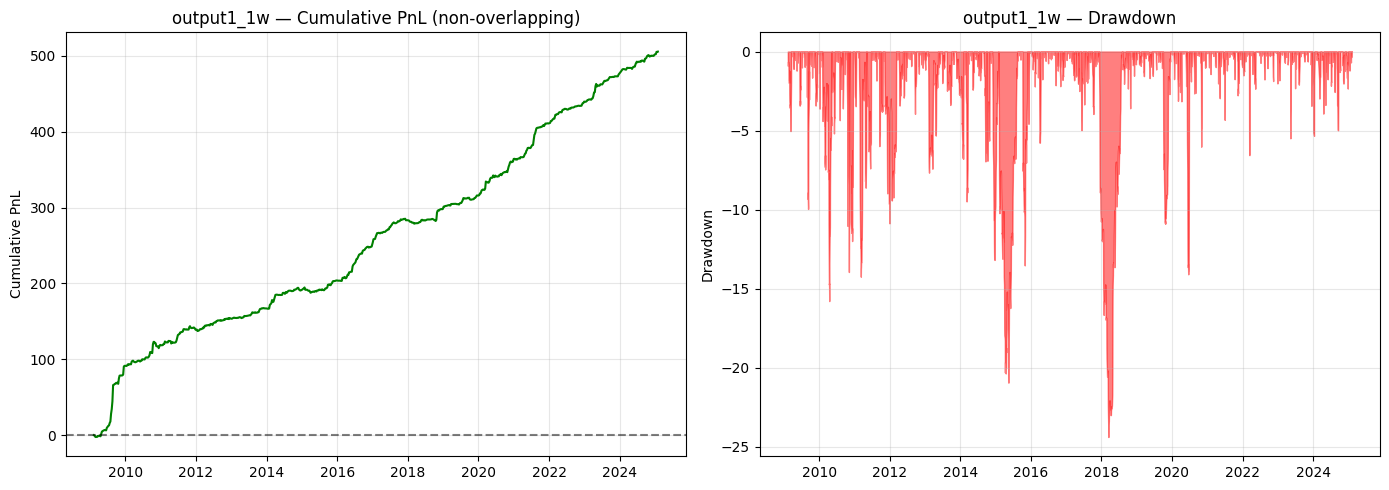


output1_1w (horizon=5d):
  IC (non-overlap):       0.505
  Hit rate (non-overlap): 66.9%
  Sharpe (annualised):    2.71
  Max drawdown:           -24.3876
  Calmar ratio:           1.37
  Win/Loss ratio:         2.52
  Avg daily turnover:     40.59%
  N obs (non-overlap):    765


c:\Users\nassi\Desktop\Projets CV\commodity-return-forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


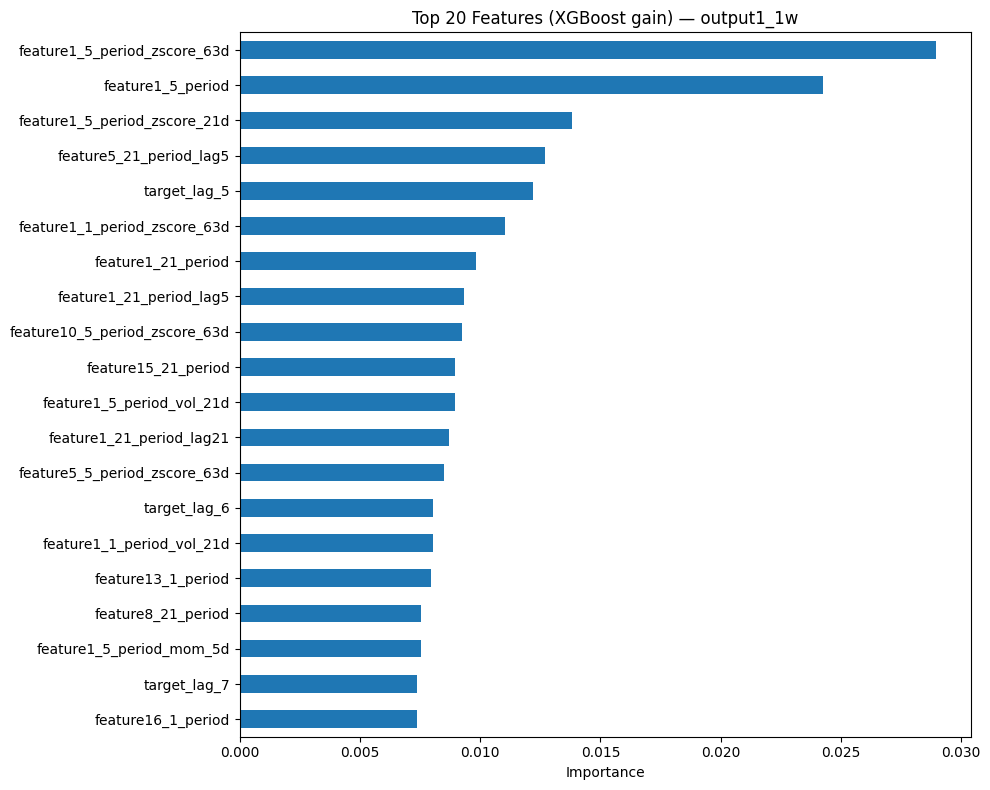


XGBoost (engineered) — output1_1m (horizon=21d)
 fold     ic  hit_rate  sharpe    max_dd
    1 0.5488    0.6216  1.5324  -59.7097
    2 0.5454    0.6486  1.6473 -113.3389
    3 0.4071    0.6486  1.5689  -35.8274
    4 0.5294    0.6216  1.4329  -47.2892
    5 0.4275    0.7027  1.5093  -34.8979

Mean: IC=0.492, Hit=64.9%, Sharpe=1.54, MaxDD=-58.2126


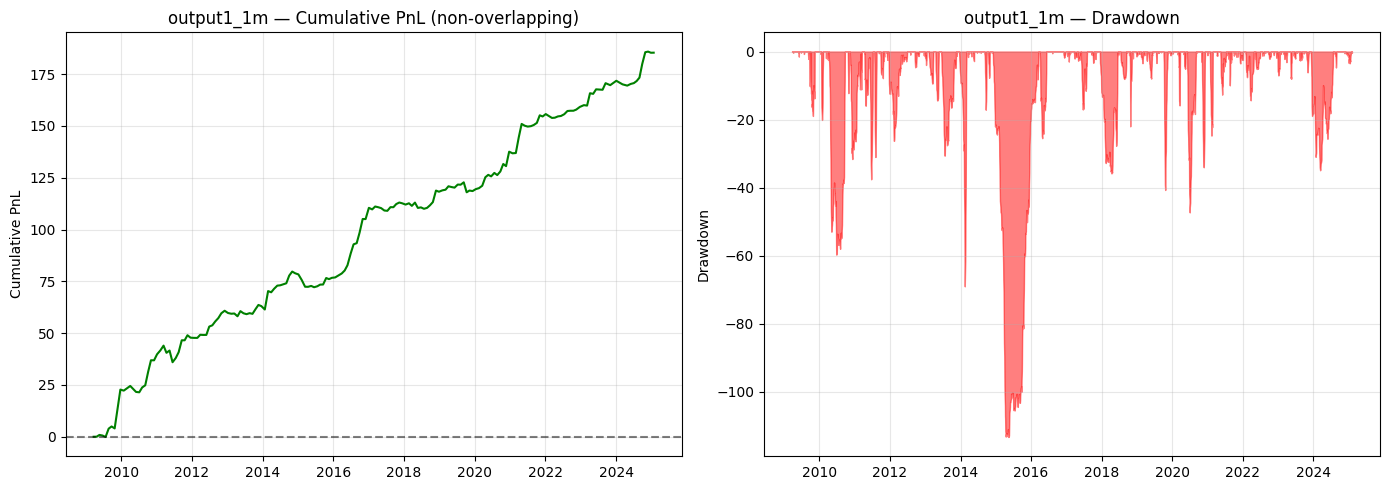


output1_1m (horizon=21d):
  IC (non-overlap):       0.461
  Hit rate (non-overlap): 64.1%
  Sharpe (annualised):    1.51
  Max drawdown:           -113.3389
  Calmar ratio:           0.11
  Win/Loss ratio:         2.34
  Avg daily turnover:     24.50%
  N obs (non-overlap):    181


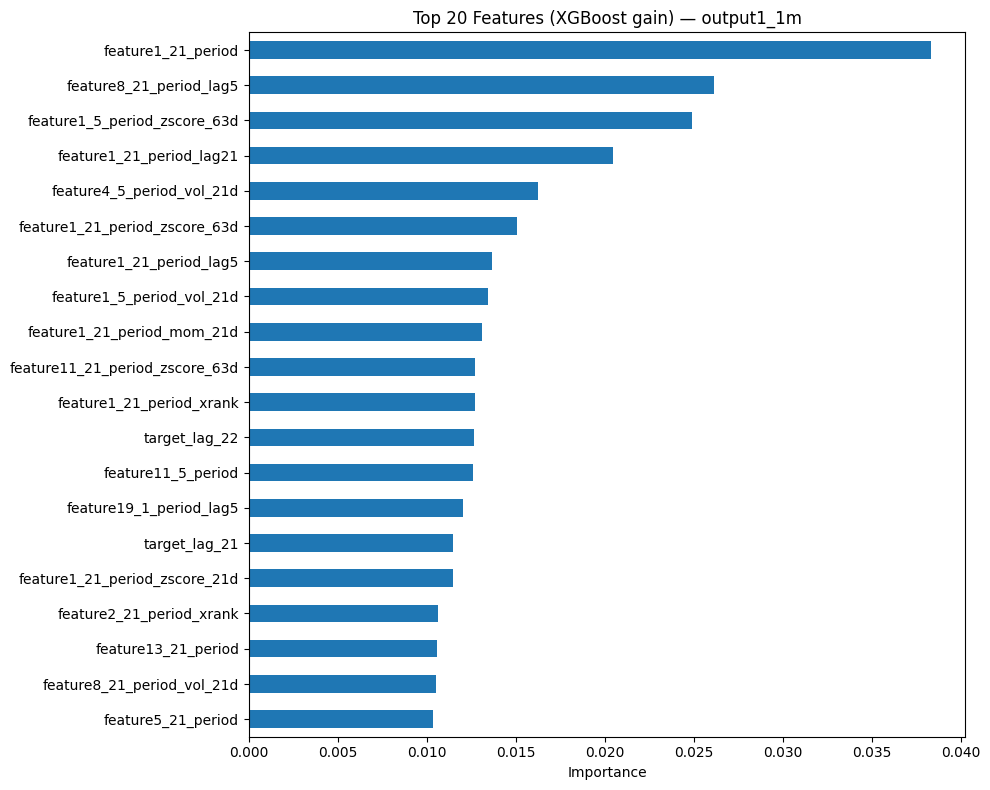

In [ ]:
# Run walk-forward on engineered features
df_eng, eng_cols = engineer_all_features(df, feature_cols)
all_cols = feature_cols + eng_cols

for target in TARGETS:
    results, oos, model = walkforward(df_eng, all_cols, target)
    print_results(results, target, 'XGBoost (engineered)')
    plot_cumulative_pnl(oos, target)
    print_backtest_stats(oos, target)
    plot_feature_importance(model, title=f'— {target}')